In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [3]:
df.shape
df.dtypes
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [4]:
df['passed'].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

In [5]:
subjects = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subjects].mean(axis=1)
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed,avg_score
0,Alice,88,92,76,80,95,92,4.5,1,86.2
1,Bob,42,55,48,50,60,65,1.2,0,51.0
2,Charlie,75,70,80,68,88,85,3.0,1,76.2
3,Diana,95,98,91,89,97,98,6.0,1,94.0
4,Eve,38,42,50,45,55,58,0.8,0,46.0


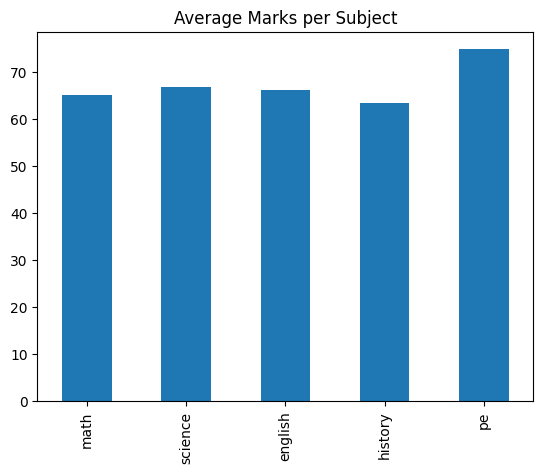

In [6]:
df[subjects].mean().plot(kind='bar')
plt.title("Average Marks per Subject")
plt.savefig("plot1_bar.png")
plt.show()

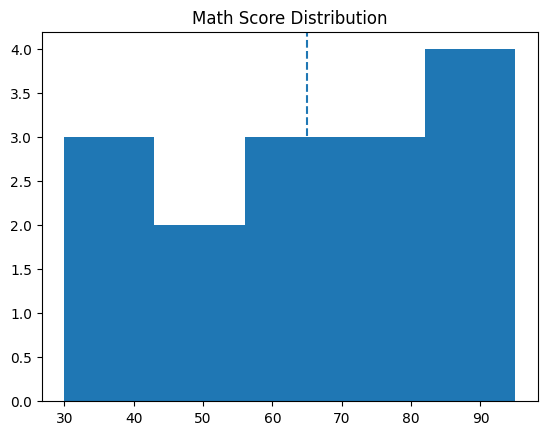

In [7]:
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Score Distribution")
plt.savefig("plot2_hist.png")
plt.show()

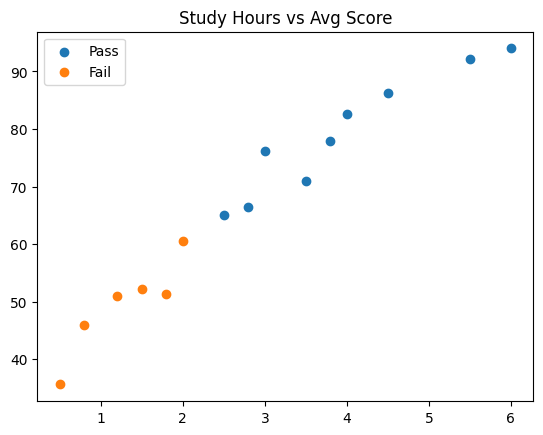

In [8]:
pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.legend()
plt.title("Study Hours vs Avg Score")
plt.savefig("plot3_scatter.png")
plt.show()

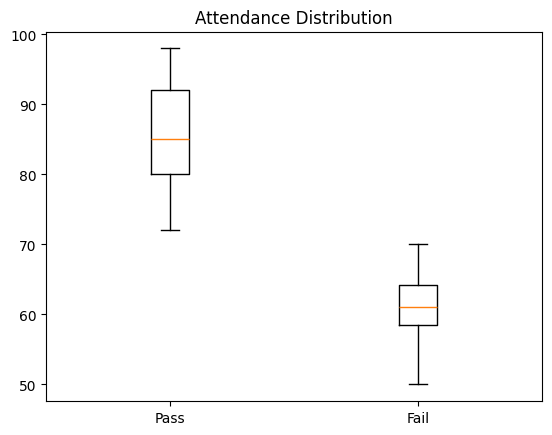

In [9]:
plt.boxplot([
    df[df['passed']==1]['attendance_pct'],
    df[df['passed']==0]['attendance_pct']
], tick_labels=["Pass","Fail"])

plt.title("Attendance Distribution")
plt.savefig("plot4_box.png")
plt.show()

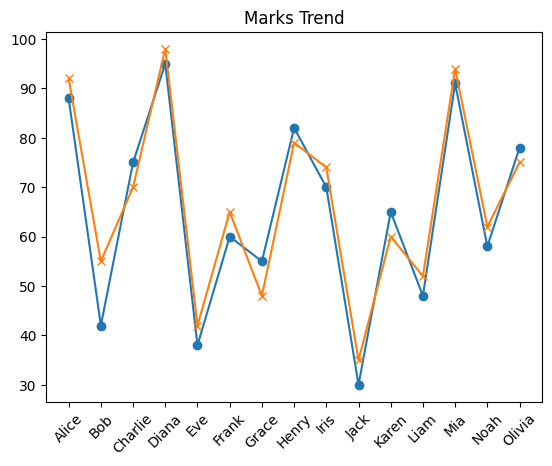

In [10]:
plt.plot(df['name'], df['math'], marker='o')
plt.plot(df['name'], df['science'], marker='x')

plt.xticks(rotation=45)
plt.title("Marks Trend")
plt.savefig("plot5_line.png")
plt.show()

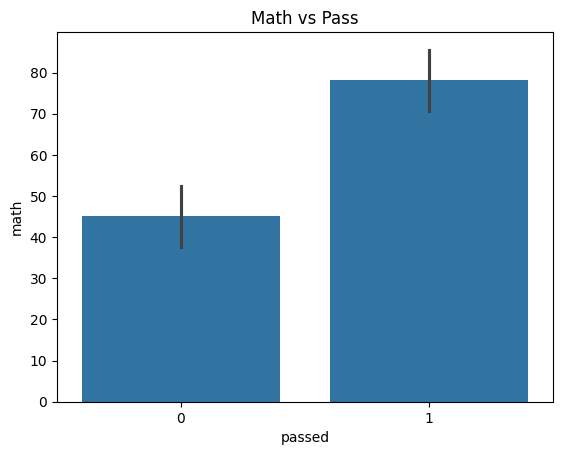

In [11]:
sns.barplot(data=df, x='passed', y='math')
plt.title("Math vs Pass")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

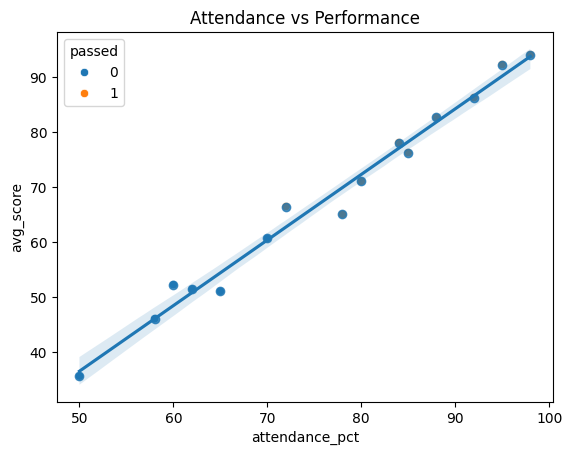

In [12]:
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')
sns.regplot(data=df, x='attendance_pct', y='avg_score')

plt.title("Attendance vs Performance")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [14]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0
